In [ ]:
!pip install -q transformers==4.40.0 peft==0.10.0 accelerate==0.29.3 datasets==2.19.0 evaluate bert_score sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.6/297.6 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 86.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.1 req

In [ ]:
import torch

MODEL_SIZE = "large"
MODEL_NAME = (
    "facebook/bart-large-cnn" if MODEL_SIZE == "large"
    else "facebook/bart-base"
)

# LoRA
LORA_R       = 8
LORA_ALPHA   = 16
LORA_DROPOUT = 0.1

# Training
BATCH_SIZE   = 1
GRAD_ACCUM   = 8
NUM_EPOCHS   = 3
LR           = 5e-4
FP16         = True
SAVE_STEPS   = 200
EVAL_STEPS   = 200
WARMUP_STEPS = 100
ADAPTER_PATH = "./bart-lora-adapter"

# Dataset splits
TRAIN_SIZE = 2000
VAL_SIZE   = 300
TEST_SIZE  = 200

# Tokenizer limits
MAX_INPUT_TOKENS  = 1024
MAX_TARGET_TOKENS = 256

# Chunking
MAX_CHUNK_WORDS    = 400
MIN_SECTION_WORDS  = 60
MATH_DENSITY_LIMIT = 0.12

# Summary length bounds
CHUNK_MIN, CHUNK_MAX = 40, 90      # pass 1 (per chunk)
FINAL_MIN, FINAL_MAX = 100, 200    # pass 2 (final merge)

device = 0 if torch.cuda.is_available() else -1

print(f"Device         : {'GPU' if device == 0 else 'CPU (slow)'}")
print(f"Model          : {MODEL_NAME}")
print(f"LoRA rank      : {LORA_R}")
print(f"FP16           : {FP16}")
print(f"Epochs         : {NUM_EPOCHS}")
print(f"Effective batch: {BATCH_SIZE * GRAD_ACCUM}")

Device         : GPU
Model          : facebook/bart-large-cnn
LoRA rank      : 8
FP16           : True
Epochs         : 3
Effective batch: 8


In [ ]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import re
import time
from collections import Counter

from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    pipeline,
)
from peft import get_peft_model, LoraConfig, TaskType, PeftModel
from tqdm import tqdm

print("Imports OK ")


Imports OK 


## Preprocessing :

In [ ]:
def clean_text(text: str) -> str:
    text = re.sub(r'@xmath\d+',        '<equation>', text)
    text = re.sub(r'@xcite',           '<citation>', text)
    text = re.sub(r'\[EQUATION\]',     '<equation>', text, flags=re.IGNORECASE)
    text = re.sub(r'\[EQ\.?\d*\]',    '<equation>', text, flags=re.IGNORECASE)
    text = re.sub(r'\\[a-zA-Z]+\{[^}]*\}', '', text)
    text = re.sub(r'\\[a-zA-Z]+',          '', text)

    # catch inline LaTeX math patterns that slip through
    text = re.sub(r'\$[^$]{1,80}\$',       '<equation>', text)   # $...$
    text = re.sub(r'\$\$[^$]+\$\$',        '<equation>', text)   # $$...$$
    text = re.sub(r'[A-Z]_\{[^}]+\}',      '',           text)   # F_{HR1}
    text = re.sub(r'[A-Za-z]+_[A-Za-z0-9]+(?=[^a-zA-Z]|$)', '', text)  # F_H, x_i
    text = re.sub(r'[a-zA-Z]+\d*[a-zA-Z]*_[a-zA-Z]+\d*', '', text)    # Fake_H, Real_HR
    text = re.sub(r'[A-Z][a-z]+(?:[A-Z][a-z]*){4,}', '', text)  # camelCase blobs

    text = re.sub(r'[ \t]+',   ' ',    text)
    text = re.sub(r'\n{3,}',   '\n\n', text)
    return text.strip()


def split_sections(text: str) -> list:
    parts = text.split("\n\n")
    return [p.strip() for p in parts if len(p.split()) >= MIN_SECTION_WORDS]


def chunk_by_sentences(text: str, max_words: int = MAX_CHUNK_WORDS) -> list:
    sentences     = re.split(r'(?<=[.!?])\s+', text)
    chunks        = []
    current       = []
    current_words = 0

    for sent in sentences:
        n = len(sent.split())
        if current_words + n <= max_words:
            current.append(sent)
            current_words += n
        else:
            if current:
                chunks.append(" ".join(current))
            current, current_words = [sent], n

    if current:
        chunks.append(" ".join(current))
    return chunks


def is_math_heavy(chunk: str) -> bool:
    tokens = chunk.split()
    if not tokens:
        return False
    return (sum(1 for t in tokens if t == '<equation>') / len(tokens)) > MATH_DENSITY_LIMIT


def build_chunks(text: str) -> list:
    """Full pipeline: clean -> section split -> sentence chunk -> drop math-heavy."""
    text     = clean_text(text)
    sections = split_sections(text)
    chunks   = []
    for section in sections:
        for chunk in chunk_by_sentences(section):
            if not is_math_heavy(chunk):
                chunks.append(chunk)
    return chunks

print("Utilities loaded")

Utilities loaded


In [ ]:
raw = load_dataset("FlameF0X/arXiv-AI-ML", split="train")
raw = raw.shuffle(seed=42)

train_ds = raw.select(range(TRAIN_SIZE))
val_ds   = raw.select(range(TRAIN_SIZE, TRAIN_SIZE + VAL_SIZE))
test_ds  = raw.select(range(TRAIN_SIZE + VAL_SIZE, TRAIN_SIZE + VAL_SIZE + TEST_SIZE))

print(f"Dataset      : FlameF0X/arXiv-AI-ML")
print(f"Total samples: {len(raw)}")
print(f"Domains      : {dict(Counter(raw['domain']))}")
print(f"\nSplits:")
print(f"  Train : {len(train_ds)}")
print(f"  Val   : {len(val_ds)}")
print(f"  Test  : {len(test_ds)}  <- held-out, untouched until final evaluation")

s = train_ds[0]
print(f"\nSample [0]:")
print(f"  Domain   : {s['domain']}")
print(f"  Content  : {len(s['content'].split())} words")
print(f"  Abstract : {len(s['abstract'].split())} words")
print(f"  Title    : {s['title']}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/2500 [00:00<?, ? examples/s]

Dataset      : FlameF0X/arXiv-AI-ML
Total samples: 2500
Domains      : {'cs.LG': 500, 'cs.CV': 500, 'cs.AI': 500, 'cs.CL': 500, 'stat.ML': 500}

Splits:
  Train : 2000
  Val   : 300
  Test  : 200  <- held-out, untouched until final evaluation

Sample [0]:
  Domain   : cs.LG
  Content  : 9174 words
  Abstract : 157 words
  Title    : Reliable Hierarchical Operating System Fingerprinting via Conformal Prediction


In [ ]:
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
vocab_size = tokenizer.vocab_size

def preprocess(examples):
    inputs  = [clean_text(c) for c in examples["content"]]
    targets = [clean_text(a) for a in examples["abstract"]]

    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_TOKENS,
        truncation=True,
        padding=False
    )

    labels = tokenizer(
        text_target=targets,
        max_length=MAX_TARGET_TOKENS,
        truncation=True,
        padding="max_length"
    )

    processed_labels = []
    for label in labels["input_ids"]:
        new_label = []
        for tok in label:
            if tok == tokenizer.pad_token_id:
                new_label.append(-100)
            else:
                new_label.append(min(tok, vocab_size - 1))
        processed_labels.append(new_label)

    model_inputs["labels"] = processed_labels
    return model_inputs

tokenized = DatasetDict({
    "train": train_ds.map(preprocess, batched=True, remove_columns=train_ds.column_names),
    "val"  : val_ds.map(preprocess,   batched=True, remove_columns=val_ds.column_names),
})

print("Tokenization complete")
print(f"  Train : {len(tokenized['train'])} examples")
print(f"  Val   : {len(tokenized['val'])} examples")
print(f"  Sample input tokens : {len(tokenized['train'][0]['input_ids'])}")
print(f"  Sample label tokens : {len(tokenized['train'][0]['labels'])}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Tokenization complete
  Train : 2000 examples
  Val   : 300 examples
  Sample input tokens : 1024
  Sample label tokens : 256


In [ ]:
import gc
torch.cuda.empty_cache()
gc.collect()

base_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
base_model.resize_token_embeddings(len(tokenizer))

lora_config = LoraConfig(
    task_type      = TaskType.SEQ_2_SEQ_LM,
    r              = LORA_R,
    lora_alpha     = LORA_ALPHA,
    lora_dropout   = LORA_DROPOUT,
    # FIX 3: correct BART attention leaf names — q/v/out projections in every block
    target_modules = ["q_proj", "v_proj", "out_proj"],
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

# Sanity check — if this is 0 LoRA attached to nothing and training will corrupt
lora_layers = [(n, p) for n, p in model.named_parameters() if "lora_" in n]
print(f"LoRA layers found: {len(lora_layers)}")
assert len(lora_layers) > 0, "LoRA didn't attach — check target_modules"


model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

trainable params: 1,769,472 || all params: 408,060,928 || trainable%: 0.43362936232895105
LoRA layers found: 216


In [ ]:
vocab_size = model.config.vocab_size
print(f"Vocab size: {vocab_size}")

for split in ["train", "val"]:
    ids = tokenized[split]["input_ids"]
    bad = [(i, max(row)) for i, row in enumerate(ids) if max(row) >= vocab_size]
    print(f"{split}: {len(bad)} bad input_ids rows")
    if bad:
        print(f"  First bad — row {bad[0][0]}, max token id {bad[0][1]}")

    labels = tokenized[split]["labels"]
    bad_labels = [
        (i, max(r for r in row if r != -100))
        for i, row in enumerate(labels)
        if any(r != -100 and r >= vocab_size for r in row)
    ]
    print(f"{split} labels: {len(bad_labels)} bad rows")

print(f"\npad_token_id  : {tokenizer.pad_token_id}")
print(f"eos_token_id  : {tokenizer.eos_token_id}")
print(f"bos_token_id  : {tokenizer.bos_token_id}")
print(f"vocab_size    : {tokenizer.vocab_size}")
print(f"len(tokenizer): {len(tokenizer)}")

Vocab size: 50265
train: 0 bad input_ids rows
train labels: 0 bad rows
val: 0 bad input_ids rows
val labels: 0 bad rows

pad_token_id  : 1
eos_token_id  : 2
bos_token_id  : 0
vocab_size    : 50265
len(tokenizer): 50265


In [ ]:
from torch.utils.data import DataLoader

# FIXED: use SafeDataCollator here too (defined below)
class SafeDataCollator(DataCollatorForSeq2Seq):
    def __call__(self, features, return_tensors=None):
        batch = super().__call__(features, return_tensors=return_tensors)
        vc = self.model.config.vocab_size
        for key in ["input_ids", "decoder_input_ids"]:
            if key in batch:
                batch[key] = batch[key].clamp(0, vc - 1)
        return batch

debug_collator = SafeDataCollator(
    tokenizer,
    model=model,
    padding=True,
    pad_to_multiple_of=None
)

loader = DataLoader(
    tokenized["train"],
    batch_size=BATCH_SIZE,
    collate_fn=debug_collator,
    shuffle=False
)

vocab_size = len(tokenizer)
print(f"Scanning batches for out-of-range tokens (vocab_size={vocab_size})...")

for step, batch in enumerate(loader):
    for key in ["input_ids", "labels", "decoder_input_ids"]:  # FIXED: added decoder_input_ids
        if key not in batch:
            continue
        ids  = batch[key]
        mask = ids != -100
        bad  = (ids * mask) >= vocab_size
        if bad.any():
            bad_vals = ids[bad].tolist()
            print(f"  Step {step} | key='{key}' | bad token IDs: {bad_vals}")
            print(f"  Rows in batch: {step * BATCH_SIZE} to {(step+1) * BATCH_SIZE - 1}")
            break
    if step > 150:
        print("No bad tokens found in first 150 steps ")
        break

print("Scan complete")

Scanning batches for out-of-range tokens (vocab_size=50265)...
No bad tokens found in first 150 steps 
Scan complete


## Model Training:

In [ ]:
data_collator = SafeDataCollator(   # FIXED: was DataCollatorForSeq2Seq
    tokenizer,
    model=model,
    padding=True,
    pad_to_multiple_of=None
)

training_args = Seq2SeqTrainingArguments(
    output_dir                  = "./bart-lora-checkpoints",
    num_train_epochs            = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    gradient_accumulation_steps = GRAD_ACCUM,
    warmup_steps                = WARMUP_STEPS,
    learning_rate               = LR,
    fp16                        = FP16,
    gradient_checkpointing      = True,
    gradient_checkpointing_kwargs = {"use_reentrant": False},
    evaluation_strategy           = "epoch",
    eval_steps                  = EVAL_STEPS,
    save_strategy               = "epoch",
    save_steps                  = SAVE_STEPS,
    save_total_limit            = 2,
    load_best_model_at_end      = True,
    predict_with_generate       = False,
    logging_steps               = 50,
    report_to                   = "none",
)

trainer = Seq2SeqTrainer(
    model            = model,
    args             = training_args,
    train_dataset    = tokenized["train"],
    eval_dataset     = tokenized["val"],
    tokenizer  = tokenizer,
    data_collator    = data_collator,
)

steps_per_epoch = len(tokenized["train"]) // (BATCH_SIZE * GRAD_ACCUM)
print(f"Starting training...")
print(f"  Steps per epoch : {steps_per_epoch}")
print(f"  Total steps     : {steps_per_epoch * NUM_EPOCHS}")
print(f"  Est. time (T4)  : ~{steps_per_epoch * NUM_EPOCHS // 4} min")

t0 = time.time()
trainer.train()
print(f"\nTraining complete  — {round((time.time() - t0) / 60, 1)} min")

/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:469: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Starting training...
  Steps per epoch : 250
  Total steps     : 750
  Est. time (T4)  : ~187 min


Epoch,Training Loss,Validation Loss
1,0.146100,0.181572
2,0.124500,0.163758
3,0.129400,0.159780


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:168: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:168: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(
/usr/local/lib/python3.12/


Training complete  — 50.4 min


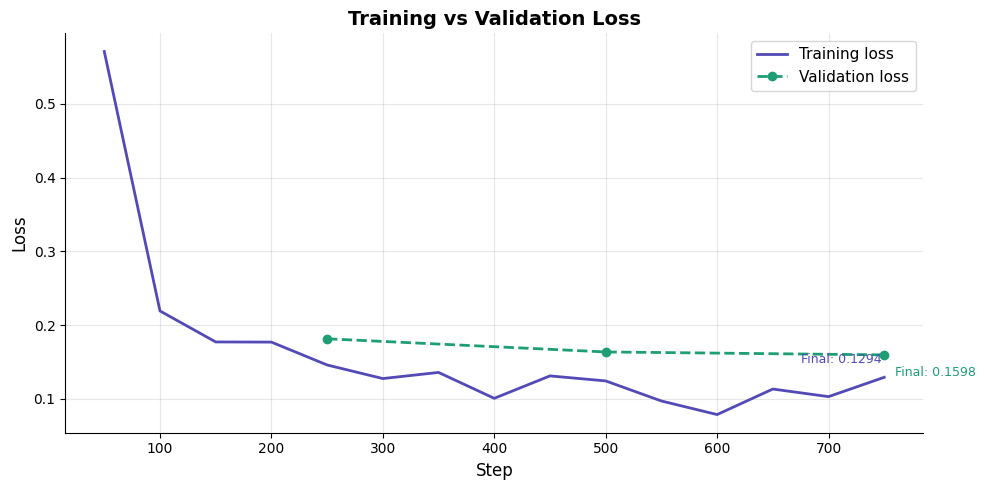

Training steps logged : 15
Validation checkpoints: 3


In [ ]:
import matplotlib.pyplot as plt

# Extract loss history from trainer
log_history = trainer.state.log_history

train_steps, train_losses = [], []
eval_steps,  eval_losses  = [], []

for entry in log_history:
    if "loss" in entry and "eval_loss" not in entry:
        train_steps.append(entry["step"])
        train_losses.append(entry["loss"])
    if "eval_loss" in entry:
        eval_steps.append(entry["step"])
        eval_losses.append(entry["eval_loss"])

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(train_steps, train_losses, color="#534AB7", linewidth=2, label="Training loss")
ax.plot(eval_steps,  eval_losses,  color="#1D9E75", linewidth=2, marker="o",
        markersize=6, linestyle="--", label="Validation loss")

ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Loss",  fontsize=12)
ax.set_title("Training vs Validation Loss", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Annotate final values
if train_losses:
    ax.annotate(f"Final: {train_losses[-1]:.4f}",
                xy=(train_steps[-1], train_losses[-1]),
                xytext=(-60, 10), textcoords="offset points",
                fontsize=9, color="#534AB7")
if eval_losses:
    ax.annotate(f"Final: {eval_losses[-1]:.4f}",
                xy=(eval_steps[-1], eval_losses[-1]),
                xytext=(8, -15), textcoords="offset points",
                fontsize=9, color="#1D9E75")

plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Training steps logged : {len(train_losses)}")
print(f"Validation checkpoints: {len(eval_losses)}")

In [ ]:
bad_inputs = []
for i, row in enumerate(tokenized["train"]["input_ids"]):
    bad_toks = [t for t in row if t >= tokenizer.vocab_size]
    if bad_toks:
        bad_inputs.append((i, bad_toks))

print(f"Bad input_id rows: {len(bad_inputs)}")
for i, toks in bad_inputs[:5]:
    print(f"  Row {i}: bad tokens {toks}")

print(f"\npad_token_id  : {tokenizer.pad_token_id}")
print(f"eos_token_id  : {tokenizer.eos_token_id}")
print(f"bos_token_id  : {tokenizer.bos_token_id}")
print(f"vocab_size    : {tokenizer.vocab_size}")
print(f"len(tokenizer): {len(tokenizer)}")

Bad input_id rows: 0

pad_token_id  : 1
eos_token_id  : 2
bos_token_id  : 0
vocab_size    : 50265
len(tokenizer): 50265


In [ ]:
model.save_pretrained(ADAPTER_PATH)
tokenizer.save_pretrained(ADAPTER_PATH)
print(f"Adapter saved to: {ADAPTER_PATH}")
print("Download from Colab file browser -> right-click the folder -> Download.")
print(os.listdir(ADAPTER_PATH))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:168: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(


Adapter saved to: ./bart-lora-adapter
Download from Colab file browser -> right-click the folder -> Download.
['tokenizer.json', 'vocab.json', 'adapter_model.safetensors', 'special_tokens_map.json', 'README.md', 'merges.txt', 'adapter_config.json', 'tokenizer_config.json']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
if not os.path.exists('/content/drive/MyDrive/bart-lora-adapter'):
    shutil.copytree('/content/bart-lora-adapter',
                    '/content/drive/MyDrive/bart-lora-adapter')
    print("Adapter saved to Drive!")
else:
    print("Already on Drive - skipping copy")

Mounted at /content/drive
Adapter saved to Drive!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# load directly from Drive, no retraining
ADAPTER_PATH = "/content/drive/MyDrive/bart-lora-adapter"

ft_base = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
tokenizer = AutoTokenizer.from_pretrained(ADAPTER_PATH)
ft_base.resize_token_embeddings(len(tokenizer))
ft_model = PeftModel.from_pretrained(ft_base, ADAPTER_PATH)
ft_model = ft_model.merge_and_unload()
ft_model = ft_model.to("cuda" if torch.cuda.is_available() else "cpu")

ft_summarizer = pipeline(
    "summarization",
    model=ft_model,
    tokenizer=tokenizer,
    device=device
)
print("Model loaded from Drive!")

Mounted at /content/drive


model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

Model loaded from Drive!


## Summarization :

In [ ]:
def run_two_pass_summary(summarizer, article_text: str) -> str:
    chunks = build_chunks(article_text)
    if not chunks:
        return "[No summarizable content found after cleaning.]"

    # RAISED: from 30 to 50 — 39-word chunks were still crashing BART
    chunks = [c for c in chunks if len(c.split()) >= 50]
    if not chunks:
        return "[All chunks were too short to summarize.]"

    chunk_summaries = []
    for chunk in chunks:
        chunk_len = len(chunk.split())
        safe_min  = min(CHUNK_MIN, max(5, chunk_len // 3))   # CHANGED: // 3 instead of // 2, more conservative
        safe_max  = min(CHUNK_MAX, max(safe_min + 10, chunk_len))  # CHANGED: cap max at input length
        try:
            out = summarizer(
                chunk,
                min_length=safe_min,
                max_length=safe_max,
                do_sample=False,
                truncation=True
            )
            chunk_summaries.append(out[0]["summary_text"])
        except Exception as e:
            print(f"   Chunk skipped: {e}")
            continue  # ADDED: skip bad chunks instead of crashing

    if not chunk_summaries:
        return "[No chunks could be summarized.]"

    combined     = " ".join(chunk_summaries)
    final_chunks = chunk_by_sentences(combined, max_words=MAX_CHUNK_WORDS)
    final_chunks = [c for c in final_chunks if len(c.split()) >= 50]  # RAISED: same threshold
    if not final_chunks:
        return combined

    final_parts = []
    for chunk in final_chunks:
        chunk_len = len(chunk.split())
        safe_min  = min(FINAL_MIN, max(10, chunk_len // 3))  # CHANGED: // 3
        safe_max  = min(FINAL_MAX, max(safe_min + 10, chunk_len))  # CHANGED: cap at input length
        try:
            out = summarizer(
                chunk,
                min_length=safe_min,
                max_length=safe_max,
                do_sample=False,
                truncation=True
            )
            final_parts.append(out[0]["summary_text"])
        except Exception as e:
            print(f"   Final chunk skipped: {e}")
            continue  # ADDED: skip bad chunks instead of crashing

    return " ".join(final_parts) if final_parts else combined

In [ ]:
SAMPLE_INDICES = [0]

for idx in SAMPLE_INDICES:
    torch.cuda.empty_cache()
    import gc; gc.collect()

    sample    = test_ds[idx]
    article   = sample["content"]
    reference = sample["abstract"]
    domain    = sample["domain"]
    title     = sample["title"]

    print(f"\n{'='*65}")
    print(f"TEST PAPER [{idx}] | Domain: {domain}")
    print(f"Title: {title}")
    print('='*65)

    chunks = build_chunks(article)
    print(f"Paper length  : {len(article.split())} words")
    print(f"Chunks (pass1): {len(chunks)}")

    print("\nGenerating summary...")
    t0      = time.time()
    summary = run_two_pass_summary(ft_summarizer, article)
    elapsed = round(time.time() - t0, 1)

    print(f"\n--- Reference (human abstract) ---")
    print(reference)
    print(f"\n--- Generated Summary ({elapsed}s) ---")
    print(summary)

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



TEST PAPER [0] | Domain: cs.CV
Title: Fake-HR1: Rethinking Reasoning of Vision Language Model for Synthetic Image Detection
Paper length  : 4160 words
Chunks (pass1): 13

Generating summary...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



--- Reference (human abstract) ---
Recent studies have demonstrated that incorporating Chain-of-Thought (CoT) reasoning into the detection process can enhance a model's ability to detect synthetic images. However, excessively lengthy reasoning incurs substantial resource overhead, including token consumption and latency, which is particularly redundant when handling obviously generated forgeries. To address this issue, we propose Fake-HR1, a large-scale hybrid-reasoning model that, to the best of our knowledge, is the first to adaptively determine whether reasoning is necessary based on the characteristics of the generative detection task. To achieve this, we design a two-stage training framework: we first perform Hybrid Fine-Tuning (HFT) for cold-start initialization, followed by online reinforcement learning with Hybrid-Reasoning Grouped Policy Optimization (HGRPO) to implicitly learn when to select an appropriate reasoning mode. Experimental results show that Fake-HR1 adaptively pe

In [ ]:
predictions = [summary]
references  = [reference]
print(f"Summary  : {len(summary.split())} words")
print(f"Reference: {len(reference.split())} words")

Summary  : 241 words
Reference: 149 words


In [ ]:
!pip install rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=d312fa224e25aef990bf00aa73c88d437c5cfe2c9d2f860d29bbdea28b09b05f
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [ ]:
import evaluate
from bert_score import score as bert_score_fn

rouge_metric = evaluate.load("rouge")
print("Evaluation metrics loaded ")

Evaluation metrics loaded 


In [ ]:
rouge_scores = rouge_metric.compute(
    predictions=predictions,
    references=references
)

print("── ROUGE Scores (fine-tuned BART, test set) ──")
print(f"  ROUGE-1 : {rouge_scores['rouge1']:.4f}")
print(f"  ROUGE-2 : {rouge_scores['rouge2']:.4f}")
print(f"  ROUGE-L : {rouge_scores['rougeL']:.4f}")
print()
print("Interpretation guide:")
print("  ROUGE-1 > 0.35 → good vocabulary overlap")
print("  ROUGE-2 > 0.10 → reasonable phrase-level match (hard for abstractive models)")
print("  ROUGE-L > 0.30 → decent structural alignment")

── ROUGE Scores (fine-tuned BART, test set) ──
  ROUGE-1 : 0.3148
  ROUGE-2 : 0.0438
  ROUGE-L : 0.1453

Interpretation guide:
  ROUGE-1 > 0.35 → good vocabulary overlap
  ROUGE-2 > 0.10 → reasonable phrase-level match (hard for abstractive models)
  ROUGE-L > 0.30 → decent structural alignment


In [ ]:
print("Computing BERTScore (this may take a few minutes)...")
P, R, F1 = bert_score_fn(
    predictions,
    references,
    lang="en",
    verbose=False
)

print("── BERTScore (fine-tuned BART, test set) ──")
print(f"  Precision : {P.mean().item():.4f}")
print(f"  Recall    : {R.mean().item():.4f}")
print(f"  F1        : {F1.mean().item():.4f}  ← main number to report")
print()
print("Interpretation guide:")
print("  F1 > 0.85 → strong semantic match")
print("  F1 > 0.80 → acceptable for domain-specific abstractive summarization")
print("  F1 < 0.75 → model may be drifting from reference content")

Computing BERTScore (this may take a few minutes)...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


── BERTScore (fine-tuned BART, test set) ──
  Precision : 0.8375
  Recall    : 0.8546
  F1        : 0.8460  ← main number to report

Interpretation guide:
  F1 > 0.85 → strong semantic match
  F1 > 0.80 → acceptable for domain-specific abstractive summarization
  F1 < 0.75 → model may be drifting from reference content


In [ ]:
print(f"Summary length  : {len(summary.split())} words")
print(f"Reference length: {len(reference.split())} words")
print(f"\nSummary preview  : {summary[:200]}")
print(f"Reference preview: {reference[:200]}")

Summary length  : 241 words
Reference length: 149 words

Summary preview  : This study seeks to improve the performance of LMMs on Synthetic Content Detection tasks. Existing methods such as GenImage (GenImage) and Community Forensics (CommunityForensics) primarily focus on b
Reference preview: Recent studies have demonstrated that incorporating Chain-of-Thought (CoT) reasoning into the detection process can enhance a model's ability to detect synthetic images. However, excessively lengthy r


In [ ]:

!pip install -q textstat

import textstat
from transformers import AutoTokenizer, AutoModelForCausalLM
from bert_score import score as bert_score_fn

print("Loading keep_it_simple...")
kis_tokenizer = AutoTokenizer.from_pretrained("philippelaban/keep_it_simple")
kis_model     = AutoModelForCausalLM.from_pretrained("philippelaban/keep_it_simple")
kis_model     = kis_model.to("cuda" if torch.cuda.is_available() else "cpu")
print("keep_it_simple ready")


def clean_for_kis(text: str) -> str:
    text = re.sub(r'<equation>|<citation>', '', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    text = re.sub(r'[ \t]+', ' ', text)
    return text.strip()


def simple_summary(bart_summary: str) -> str:
    cleaned = clean_for_kis(bart_summary)


    input_text = cleaned + " " + kis_tokenizer.bos_token
    inputs     = kis_tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(kis_model.device)

    with torch.no_grad():
        output_ids = kis_model.generate(
            **inputs,
            max_new_tokens=150,
            min_new_tokens=40,
            do_sample=False,
            no_repeat_ngram_size=3,
        )

    # decode only the newly generated tokens, not the input
    generated = output_ids[0][inputs["input_ids"].shape[-1]:]
    return kis_tokenizer.decode(generated, skip_special_tokens=True).strip()

print("\nGenerating simple summary...")
simple = simple_summary(summary)

print("\n--- Technical Summary (BART) ---")
print(summary)
print("\n--- Simple Summary (keep_it_simple) ---")
print(simple)


fk_technical  = textstat.flesch_kincaid_grade(summary)
fk_simple     = textstat.flesch_kincaid_grade(simple)
fre_technical = textstat.flesch_reading_ease(summary)
fre_simple    = textstat.flesch_reading_ease(simple)

print("\n── Readability ──────────────────────────────")
print(f"  {'':25s} {'Technical':>12} {'Simple':>10}")
print(f"  {'Flesch-Kincaid Grade':25s} {fk_technical:>12.1f} {fk_simple:>10.1f}")
print(f"  {'Flesch Reading Ease':25s} {fre_technical:>12.1f} {fre_simple:>10.1f}")
print(f"  (Reading Ease: 0=hardest, 100=easiest)")


print("\nComputing BERTScore...")
P_t, R_t, F_t = bert_score_fn([summary], [reference], lang="en", verbose=False)
P_s, R_s, F_s = bert_score_fn([simple],  [reference], lang="en", verbose=False)

print("\n── BERTScore vs original abstract ───────────")
print(f"  {'':25s} {'Technical':>12} {'Simple':>10}")
print(f"  {'Precision':25s} {P_t.mean().item():>12.4f} {P_s.mean().item():>10.4f}")
print(f"  {'Recall':25s} {R_t.mean().item():>12.4f} {R_s.mean().item():>10.4f}")
print(f"  {'F1':25s} {F_t.mean().item():>12.4f} {F_s.mean().item():>10.4f}")
print(f"\n  Note: simple summary is expected to score lower —")
print(f"  it targets readability, not abstract similarity.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 66.8 MB/s eta 0:00:00
Loading keep_it_simple...


tokenizer_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.44G [00:00<?, ?B/s]

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


keep_it_simple ready

Generating simple summary...

--- Technical Summary (BART) ---
This study seeks to improve the performance of LMMs on Synthetic Content Detection tasks. Existing methods such as GenImage (GenImage) and Community Forensics (CommunityForensics) primarily focus on binary detection, providing insufficient evaluation of LRMs' reasoning capabilities. While datasets such as FakeClue (FakeClue) and FakeBench (FakeBench) are closer to our objectives, they require models to produce reasoning chains even to the best of our objectives. To this end, we propose a simple yet effective dual-mode data strategy, which systematically partitions existing datasets into reasoning and non-reasoning subsets, thereby avoiding the need for costly manual annotation. As illustrated in Figure 1, our approach leverages two targeted heuristics depending on the query type: (i) Data-oriented heuristic (low-cost acquisition of reasoning-and-non-reasoned data): Existing hybrid reasoning methods als

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



── BERTScore vs original abstract ───────────
                               Technical     Simple
  Precision                       0.8375     0.8547
  Recall                          0.8546     0.8276
  F1                              0.8460     0.8410

  Note: simple summary is expected to score lower —
  it targets readability, not abstract similarity.


In [ ]:
!pip install pyngrok

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

!pip install -q streamlit pyngrok textstat
!streamlit run app.py --server.port 8501 &>/dev/null &

import time; time.sleep(3)

from pyngrok import ngrok
ngrok.kill()
ngrok.set_auth_token("3Chtzo9CMYv46yVJ1YtsusIileL_2Ukk6BqnP7QDhEdso8wxQ")   # free at ngrok.com
public_url = ngrok.connect(8501)
print(f"\n App live at: {public_url}")


 App live at: NgrokTunnel: "https://lance-feel-rectangle.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
SAMPLE_INDICES = [0]

for idx in SAMPLE_INDICES:
      sample    = test_ds[idx]
      article   = sample["content"]
      reference = sample["abstract"]
print(article)


FAKE-HR1: RETHINKING REASONING OF VISION LANGUAGE MODEL FOR
SYNTHETIC IMAGE DETECTION
Changjiang Jiang1,2
Xinkuan Sha2
Fengchang Yu1∗
Jingjing Liu2†
Jian Liu2‡
Mingqi Fang2
Chenfeng Zhang2,3
Wei Lu1
1 Wuhan University
2AntGroup
3Zhejiang University
ABSTRACT
Recent studies have demonstrated that incorporating Chain-of-
Thought (CoT) reasoning into the detection process can enhance a
model’s ability to detect synthetic images. However, excessively
lengthy reasoning incurs substantial resource overhead, including
token consumption and latency, which is particularly redundant
when handling obviously generated forgeries. To address this issue,
we propose Fake-HR1, a large-scale hybrid-reasoning model that,
to the best of our knowledge, is the first to adaptively determine
whether reasoning is necessary based on the characteristics of the
generative detection task. To achieve this, we design a two-stage
training framework: we first perform Hybrid Fine-Tuning (HFT) for
cold-start initializati

In [ ]:
SAMPLE_INDICES = [0]

for idx in SAMPLE_INDICES:
      sample    = test_ds[idx]
      article   = sample["content"]
      reference = sample["abstract"]
print(reference)

Recent studies have demonstrated that incorporating Chain-of-Thought (CoT) reasoning into the detection process can enhance a model's ability to detect synthetic images. However, excessively lengthy reasoning incurs substantial resource overhead, including token consumption and latency, which is particularly redundant when handling obviously generated forgeries. To address this issue, we propose Fake-HR1, a large-scale hybrid-reasoning model that, to the best of our knowledge, is the first to adaptively determine whether reasoning is necessary based on the characteristics of the generative detection task. To achieve this, we design a two-stage training framework: we first perform Hybrid Fine-Tuning (HFT) for cold-start initialization, followed by online reinforcement learning with Hybrid-Reasoning Grouped Policy Optimization (HGRPO) to implicitly learn when to select an appropriate reasoning mode. Experimental results show that Fake-HR1 adaptively performs reasoning across different ty

In [ ]:
import os
print(os.path.exists('/content/bart-lora-adapter'))
print(os.path.exists('/content/app.py'))

False
False
